In [ ]:
# Importing Libraries

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:

from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
# Loading Dataset

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/balanced_dataset.csv")

In [ ]:
df.head()

,Unnamed: 0,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,262610,160562.0,-2.816694,-3.213930,-3.480632,1.928768,-4.125789,1.510402,6.785640,-0.386568,...,1.179046,0.337434,3.920742,-0.430976,0.413755,-0.612745,-0.593538,0.161113,1714.00,0
1,197606,132094.0,2.067563,-0.659638,-2.458499,-0.304291,-0.001905,-1.821105,0.704465,-0.716606,...,-0.048622,0.273420,-0.170881,0.116267,0.455344,1.007802,-0.142258,-0.075698,106.00,0
2,3398,2922.0,-0.992595,0.399507,1.052572,0.574846,1.308590,0.018082,0.817578,0.078251,...,-0.271119,-1.182435,-0.016922,-1.028080,0.428775,-0.547555,0.008129,0.072269,83.08,0
3,168251,119136.0,0.919725,-2.541842,-3.283809,-0.063653,-0.209552,-0.985068,1.434683,-0.742365,...,0.338952,0.058458,-0.773998,-0.367953,0.303598,0.954496,-0.252335,0.013850,695.96,0
4,111778,72365.0,0.893150,-0.450049,1.512255,1.712861,-0.955363,0.990251,-0.745713,0.438968,...,-0.151391,-0.073795,-0.026115,0.258404,0.391343,-0.417291,0.094698,0.035066,70.00,0


In [ ]:
df.shape

(984, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  984 non-null    int64  
 1   Time        984 non-null    float64
 2   V1          984 non-null    float64
 3   V2          984 non-null    float64
 4   V3          984 non-null    float64
 5   V4          984 non-null    float64
 6   V5          984 non-null    float64
 7   V6          984 non-null    float64
 8   V7          984 non-null    float64
 9   V8          984 non-null    float64
 10  V9          984 non-null    float64
 11  V10         984 non-null    float64
 12  V11         984 non-null    float64
 13  V12         984 non-null    float64
 14  V13         984 non-null    float64
 15  V14         984 non-null    float64
 16  V15         984 non-null    float64
 17  V16         984 non-null    float64
 18  V17         984 non-null    float64
 19  V18         984 non-null    f

In [ ]:
df.describe()

,Unnamed: 0,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,130332.789634,87566.181911,-2.334540,1.823893,-3.460086,2.326527,-1.590445,-0.757901,-2.780060,0.293395,...,0.364119,0.026623,-0.008088,-0.038687,0.009988,0.025186,0.081650,0.028808,99.185183,0.500000
std,81626.556944,46994.212214,5.499792,3.640813,6.238495,3.159776,4.180866,1.662825,5.847007,4.846715,...,2.778026,1.157000,1.150300,0.543045,0.657190,0.483542,1.003171,0.441130,216.139663,0.500254
min,39.000000,29.000000,-30.552380,-8.402154,-31.103685,-3.925581,-22.105532,-6.406267,-43.557242,-41.044261,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.273985,-7.263482,-4.987659,0.000000,0.000000
25%,57111.750000,47755.750000,-2.797252,-0.080046,-5.084967,-0.064885,-1.775001,-1.606496,-3.044451,-0.194925,...,-0.158248,-0.516057,-0.219356,-0.380768,-0.329563,-0.293210,-0.067771,-0.059069,1.290000,0.000000
50%,134679.000000,80914.000000,-0.762189,0.964356,-1.196086,1.411577,-0.463655,-0.657739,-0.652830,0.123062,...,0.163853,0.067800,-0.020772,0.013635,0.035952,-0.006261,0.046455,0.032629,17.995000,0.500000
75%,197637.750000,132108.750000,1.032750,2.765175,0.378391,4.234699,0.482491,0.026012,0.295427,0.853411,...,0.645756,0.589674,0.206849,0.380530,0.394096,0.319513,0.447789,0.218519,99.922500,1.000000
max,283580.000000,171708.000000,2.329291,22.057729,3.084593,12.114672,11.095089,6.474115,6.785640,20.007208,...,27.202839,8.361985,5.466230,1.215435,2.208209,2.745261,3.444603,1.779364,2125.870000,1.000000


In [ ]:
# Checking Missing Values
df.isnull().sum()

,0
Unnamed: 0,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0


In [ ]:
# Checking Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Class Imbalance Analysis

In [ ]:
df['Class'].value_counts()

,count
Class,
0,492
1,492


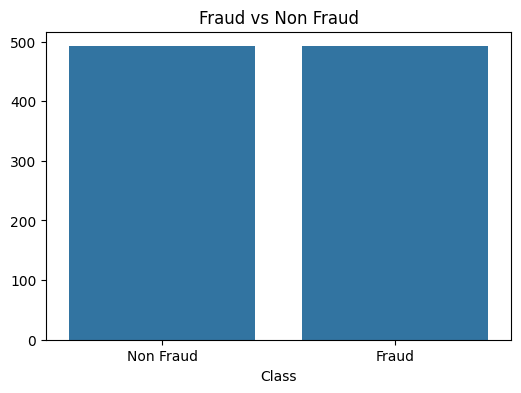

In [ ]:
fraud = df['Class'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=fraud.index,y=fraud.values)
plt.xticks([0,1],["Non Fraud","Fraud"])
plt.title("Fraud vs Non Fraud")
plt.show()

In [ ]:
# Percentage
fraud_percentage = (df['Class'].sum()/len(df))*100

print(f"Fraud Transactions: {fraud_percentage:.4f}%")

Fraud Transactions: 50.0000%


In [ ]:
# Distribution of Transaction Amount

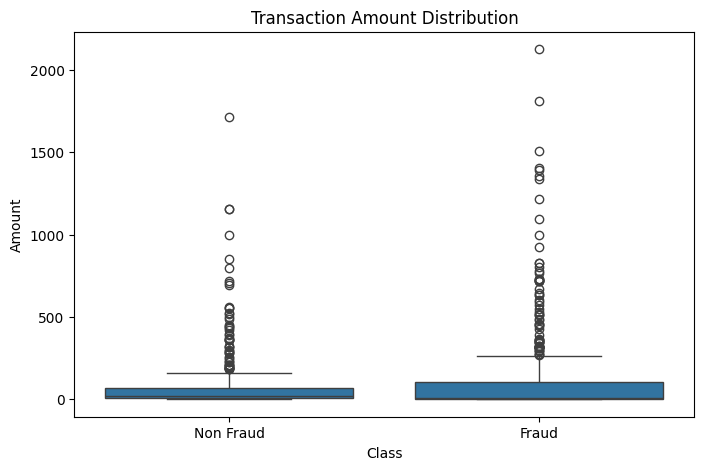

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class',y='Amount',data=df)

plt.xticks([0,1],["Non Fraud","Fraud"])

plt.title("Transaction Amount Distribution")

plt.show()

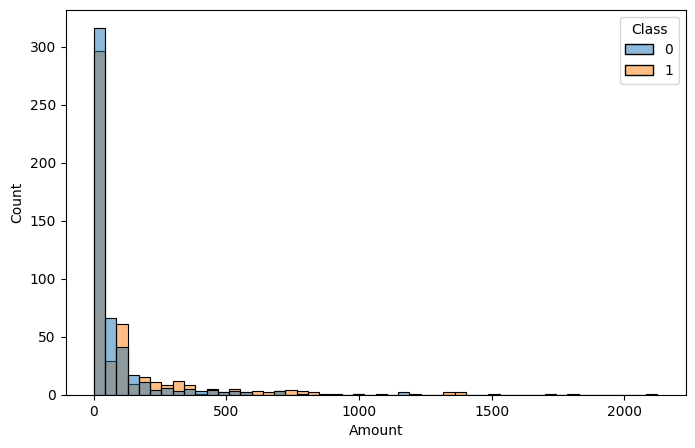

In [ ]:
# Histogram
plt.figure(figsize=(8,5))

sns.histplot(data=df,x='Amount',hue='Class',bins=50)

plt.show()

In [ ]:
# Time of Day Analysis

In [ ]:
# Converting seconds into hours
df['Hour']=df['Time']//3600

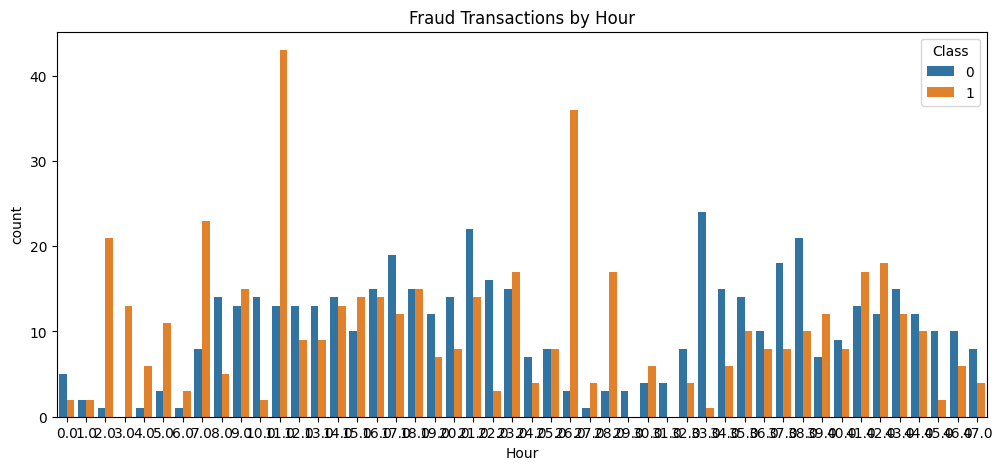

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(x='Hour',hue='Class',data=df)

plt.title("Fraud Transactions by Hour")

plt.show()

In [ ]:
# Feature Scaling

In [ ]:
scaler = StandardScaler()

df['Amount']=scaler.fit_transform(df[['Amount']])

df['Time']=scaler.fit_transform(df[['Time']])

In [ ]:
# Train Test Split

In [ ]:
X=df.drop('Class',axis=1)

y=df['Class']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.2,
random_state=42,
stratify=y

)

In [ ]:
# Applying SMOTE

In [ ]:
smote=SMOTE(random_state=42)

X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

In [ ]:
# Checking
y_train_smote.value_counts()

,count
Class,
0,394
1,394


In [ ]:
# Logistic Regression

In [ ]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train_smote,y_train_smote)

pred_lr=lr.predict(X_test)

prob_lr=lr.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Random Forest

In [ ]:
rf=RandomForestClassifier(

n_estimators=100,

random_state=42

)

rf.fit(X_train_smote,y_train_smote)

pred_rf=rf.predict(X_test)

prob_rf=rf.predict_proba(X_test)[:,1]

In [ ]:
# Evaluation Function

In [ ]:
def evaluate(y_test,pred,prob):

    print("Accuracy :",accuracy_score(y_test,pred))

    print("Precision :",precision_score(y_test,pred))

    print("Recall :",recall_score(y_test,pred))

    print("F1 Score :",f1_score(y_test,pred))

    print("ROC AUC :",roc_auc_score(y_test,prob))

    print("\nClassification Report\n")

    print(classification_report(y_test,pred))

In [ ]:
evaluate(y_test,pred_lr,prob_lr)
# Logistic Regression

Accuracy : 0.9746192893401016
Precision : 0.9894736842105263
Recall : 0.9591836734693877
F1 Score : 0.9740932642487047
ROC AUC : 0.9851576994434137

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.99      0.98        99
           1       0.99      0.96      0.97        98

    accuracy                           0.97       197
   macro avg       0.98      0.97      0.97       197
weighted avg       0.98      0.97      0.97       197



In [ ]:
evaluate(y_test,pred_rf,prob_rf)
# Random Forest

Accuracy : 0.9644670050761421
Precision : 0.9789473684210527
Recall : 0.9489795918367347
F1 Score : 0.9637305699481865
ROC AUC : 0.9841785198928056

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        99
           1       0.98      0.95      0.96        98

    accuracy                           0.96       197
   macro avg       0.96      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197



In [ ]:
# Confusion Matrix

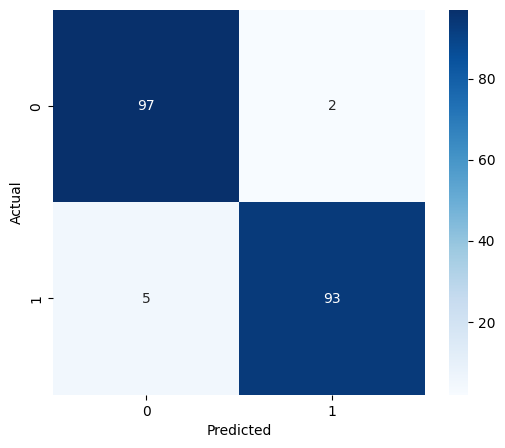

In [ ]:
cm=confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ROC Curve

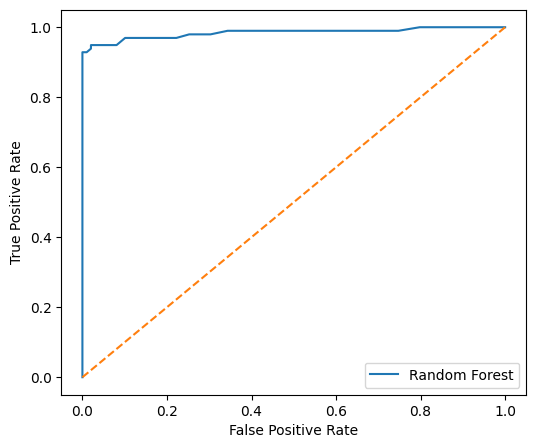

In [ ]:
fpr,tpr,_=roc_curve(y_test,prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [ ]:
# Feature Importance

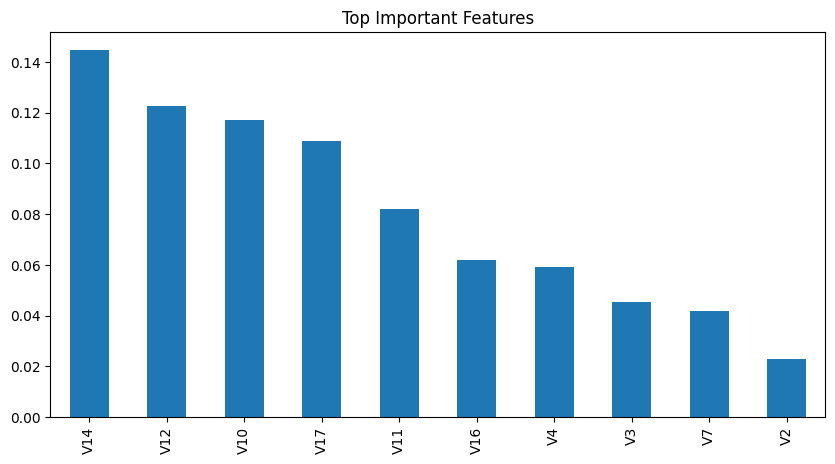

In [ ]:
importance=pd.Series(

rf.feature_importances_,

index=X.columns

).sort_values(ascending=False)

importance.head(10).plot(

kind='bar',

figsize=(10,5)

)

plt.title("Top Important Features")

plt.show()

In [ ]:
# Saving Model

In [153]:
import joblib

joblib.dump(rf,"fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [ ]:
# Conclusion

In [ ]:
# Load and analyze the dataset
# Analyze class imbalance and calculate fraud percentage
# Perform EDA (transaction amount and time-of-day analysis)
# Explain why accuracy is misleading
# Handle class imbalance using SMOTE
# Stratified train-test split
# Train two models (Logistic Regression and Random Forest)
# Evaluate using Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, and ROC Curve
# Discuss Recall vs Precision trade-off
# Perform feature importance analysis
# Discuss scalability for handling 1 million transactions/hour
# Save the trained model